# 05 · Attention & the KV Cache — a deep dive

This is the empirical foundation for the lab's research thread: **memory and context-window limitations**. A transformer's only "memory" during a forward pass is (a) what sits in the prompt and (b) the **KV cache** built from it. Here we measure, on real hardware (MPS), exactly what that memory costs and where it breaks:

1. **The KV cache, exactly** — derive its size and confirm it against the live cache object.
2. **What context length costs** — prefill latency, per-token decode latency, and KV memory as functions of length.
3. **Attention sinks & positional structure** — where attention actually goes (and why naive cache eviction fails).
4. **Recall probes** — a single needle (trivial even at 4k) vs many near-identical keys (where a 0.5B model's recall cracks and a *recency bias* appears).

Reusable code: `llmlab/inspect/{profiling,attention,longcontext}.py`; tests: `tests/test_inspect.py`."

In [ ]:
import sys
from pathlib import Path

LLM_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(LLM_DIR) not in sys.path:
    sys.path.insert(0, str(LLM_DIR))

import warnings
warnings.filterwarnings("ignore")
import transformers
transformers.logging.set_verbosity_error()

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from llmlab import config
from llmlab.models.local_model import LocalModel, SamplingConfig, kv_cache_shapes
from llmlab.inspect import profiling as prof
from llmlab.inspect import attention as attn
from llmlab.inspect import longcontext as lc

config.configure_caches()
config.ensure_dirs()
config.seed_everything(0)
print("device:", config.get_device(), "| torch:", torch.__version__)

device: mps | torch: 2.12.1


## 1. The KV cache, exactly

At each step the model caches the **keys** and **values** of every token so it never recomputes them. The size is fully determined by the architecture:

$$\text{bytes} = 2 \times n_{\text{layers}} \times n_{\text{kv-heads}} \times d_{\text{head}} \times \text{seq} \times \text{bytes/elem}$$

The factor 2 is keys + values; note it uses **key/value** heads (GQA), not query heads. Let's confirm the formula against the live `Cache` object, then watch it grow by exactly one position per decode step.

In [ ]:
# Primary runtime: memory-efficient SDPA attention, used for every quantitative
# sweep (it scales to long contexts without materialising the full L x L score
# matrix). A small eager twin appears in Section 3 only, to read attention
# weights — which SDPA does not expose.
lm = LocalModel("Qwen/Qwen2.5-0.5B-Instruct", dtype="float32", attn_implementation="sdpa")
cfg = lm.model.config
n_kv = getattr(cfg, "num_key_value_heads", cfg.num_attention_heads)
head_dim = getattr(cfg, "head_dim", cfg.hidden_size // cfg.num_attention_heads)
dtype_bytes = torch.finfo(next(lm.model.parameters()).dtype).bits // 8

messages = [{"role": "user", "content": "Summarize the water cycle in two sentences."}]
inputs, outputs = lm.forward(messages)  # forward() runs with use_cache=True
seq = inputs["input_ids"].shape[-1]

# Measure the live cache and compare to the analytical formula.
shapes = kv_cache_shapes(outputs.past_key_values)
measured_bytes = dtype_bytes * sum(
    (k[0] * k[1] * k[2] * k[3]) + (v[0] * v[1] * v[2] * v[3]) for k, v in shapes
)
analytic_bytes = prof.kv_cache_bytes(cfg.num_hidden_layers, n_kv, head_dim, seq, dtype_bytes)
kv_exact = measured_bytes == analytic_bytes

print(f"prompt length     : {seq} tokens")
print(f"layer-0 key shape  : {shapes[0][0]}  (batch, kv_heads, seq, head_dim)")
print(f"analytic KV bytes  : {analytic_bytes:,}")
print(f"measured KV bytes  : {measured_bytes:,}")
print(f"formula exact?     : {kv_exact}")
assert kv_exact

# One decode step extends the cache by exactly one position.
nxt = outputs.logits[:, -1:, :].argmax(-1)
mask2 = torch.cat([inputs["attention_mask"], torch.ones_like(nxt)], dim=-1)
out2 = lm.model(input_ids=nxt, attention_mask=mask2,
                past_key_values=outputs.past_key_values, use_cache=True)
print(f"\ncache seq after 1 decode step: {seq} -> {kv_cache_shapes(out2.past_key_values)[0][0][2]}")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

prompt length     : 39 tokens
layer-0 key shape  : (1, 2, 39, 64)  (batch, kv_heads, seq, head_dim)
analytic KV bytes  : 958,464
measured KV bytes  : 958,464
formula exact?     : True



cache seq after 1 decode step: 39 -> 40


## 2. What context length costs

Two phases, two cost curves. **Prefill** processes the whole prompt in one pass (attention compute is $O(L^2)$). **Decode** then emits one token at a time, and each step must attend over the *entire* cache — so per-token latency creeps up with context length while the KV cache grows strictly linearly. We sweep length with random tokens (content is irrelevant to cost) and measure all three.

In [ ]:
scale_lengths = [128, 256, 512, 1024, 2048, 4096]
points = prof.context_scaling(lm.model, scale_lengths, n_decode=8)

df = pd.DataFrame([p.__dict__ for p in points])
df["prefill_ms"] = df["prefill_s"] * 1000
df["decode_ms_per_tok"] = df["decode_s_per_tok"] * 1000
df[["seq_len", "prefill_ms", "decode_ms_per_tok", "kv_mib", "mps_alloc_mib"]].round(2)

,seq_len,prefill_ms,decode_ms_per_tok,kv_mib,mps_alloc_mib
0,128,52.85,22.69,3.0,2012.81
1,256,87.26,23.66,6.0,2099.31
2,512,173.48,37.49,12.0,2235.38
3,1024,371.71,30.72,24.0,2544.14
4,2048,894.80,39.28,48.0,3161.65
5,4096,2551.56,57.24,96.0,4701.68


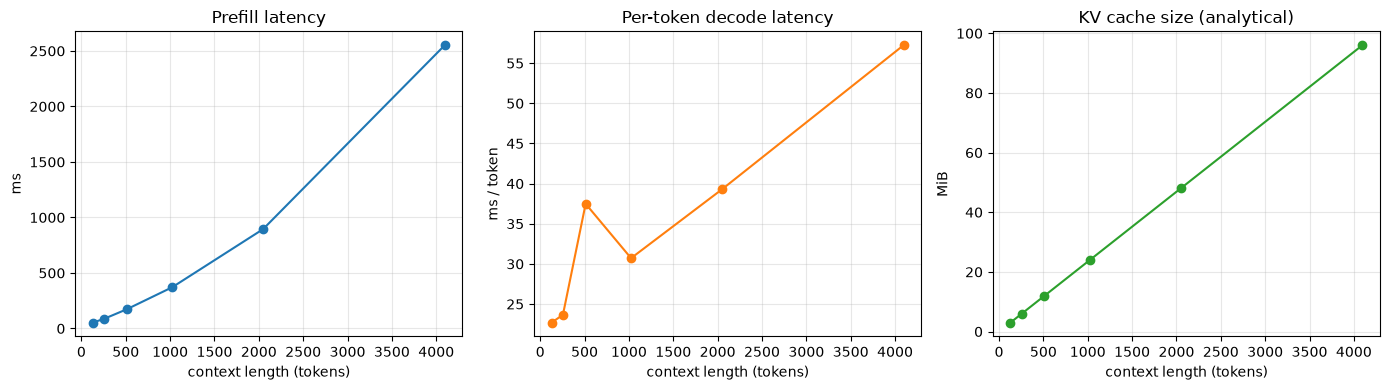

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(df.seq_len, df.prefill_ms, "o-")
axes[0].set_title("Prefill latency")
axes[0].set_ylabel("ms")
axes[1].plot(df.seq_len, df.decode_ms_per_tok, "o-", color="tab:orange")
axes[1].set_title("Per-token decode latency")
axes[1].set_ylabel("ms / token")
axes[2].plot(df.seq_len, df.kv_mib, "o-", color="tab:green")
axes[2].set_title("KV cache size (analytical)")
axes[2].set_ylabel("MiB")
for ax in axes:
    ax.set_xlabel("context length (tokens)")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Attention sinks & positional structure

Where does attention go? Three per-layer summaries of the **last query token**:

- **Sink** — attention mass on token 0. Models park large probability on the first token as a no-op (StreamingLLM). This is why dropping early tokens to shrink the cache is so damaging.
- **Entropy** — peaked (a few tokens) vs diffuse (spread out).
- **Mean distance** — local/recency vs genuinely long-range layers.

These are exactly the signals a cache-compression or eviction policy must respect.

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

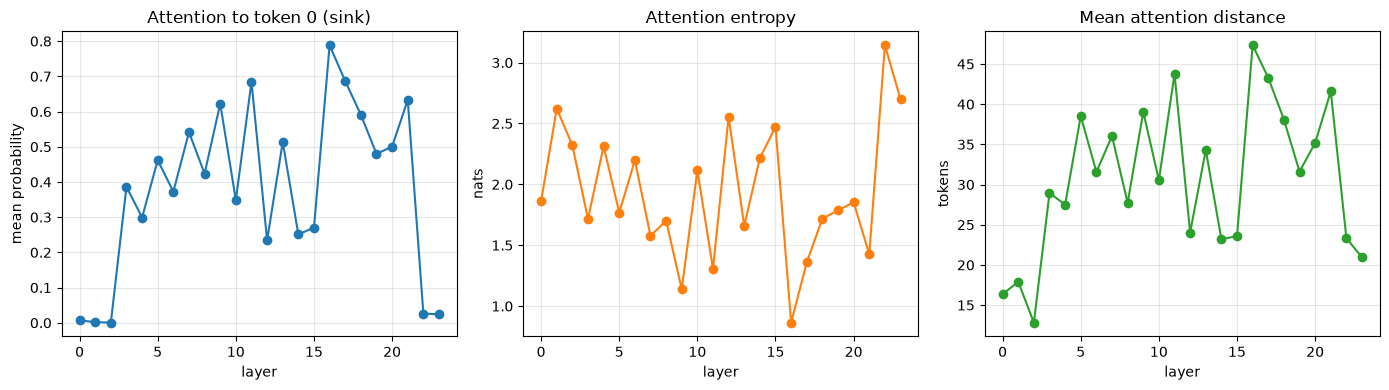

strongest single-head sink: 1.00 of all mass, in layer 11


In [ ]:
# SDPA can't return attention weights, so load a small eager twin just for this.
lm_eager = LocalModel("Qwen/Qwen2.5-0.5B-Instruct", dtype="float32", attn_implementation="eager")
prompt = [{"role": "user", "content": (
    "The capital of France is Paris. The capital of Japan is Tokyo. "
    "In which of those two countries is the Eiffel Tower located?"
)}]
_, aout = lm_eager.forward(prompt, output_attentions=True)

sink = attn.attention_to_first_token(aout.attentions)
entropy = attn.attention_entropy(aout.attentions)
distance = attn.mean_attention_distance(aout.attentions)
layers = list(range(len(sink)))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(layers, sink, "o-")
axes[0].set_title("Attention to token 0 (sink)")
axes[0].set_ylabel("mean probability")
axes[1].plot(layers, entropy, "o-", color="tab:orange")
axes[1].set_title("Attention entropy")
axes[1].set_ylabel("nats")
axes[2].plot(layers, distance, "o-", color="tab:green")
axes[2].set_title("Mean attention distance")
axes[2].set_ylabel("tokens")
for ax in axes:
    ax.set_xlabel("layer")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Sinks are usually a few specific heads, not whole layers.
head_sink = attn.head_attention_to_first_token(aout.attentions)
top_layer = int(head_sink.max(dim=1).values.argmax())
print(f"strongest single-head sink: {head_sink.max():.2f} of all mass, in layer {top_layer}")

## 4. Recall probes: when does in-context memory fail?

A model's context *is* its working memory — but having a token in context doesn't mean it can use it. Two probes on the **same** 0.5B model make the point:

- **Single needle** — one secret number in low-entropy filler. *Trivial*: the lone number stands out, so recall stays ~100% to thousands of tokens (modern small models are genuinely good at this).
- **Many keys** — 20 structurally identical `Passkey number i is V.` lines; we ask for a *specific* index. Now the model must locate one item among confusable distractors, and recall cracks — with a clear **recency bias**: late keys survive, early ones are lost.

The lesson for the lab: long context $\neq$ usable memory, and difficulty is driven by *interference*, not length alone. That gap is what retrieval and compression (Notebooks 08–10) exist to close.

In [ ]:
# Part A — a single needle is easy, even deep into the context.
single = lc.run_passkey_grid(lm, lengths=[1024, 4096], depths=[0.1, 0.5, 0.9], seed=0)
sdf = pd.DataFrame([r.__dict__ for r in single])
print(f"single-needle recall: {sdf.hit.mean():.0%}  (over a length x depth grid)")
sdf[["n_tokens", "depth", "answer", "hit"]]

single-needle recall: 100%  (over a length x depth grid)


,n_tokens,depth,answer,hit
0,1024,0.1,60494,True
1,1024,0.5,65125,True
2,1024,0.9,15306,True
3,4096,0.1,43936,True
4,4096,0.5,77013,True
5,4096,0.9,73691,True


In [ ]:
# Part B — 20 confusable keys; ask for a specific index at each context length.
multi = lc.run_multikey_grid(lm, lengths=[1024, 2048, 4096], n_keys=20, seed=0)
mdf = pd.DataFrame([r.__dict__ for r in multi])
print(f"multi-key recall: {mdf.hit.mean():.0%}  (vs ~100% for a single needle)")
print("\nrecall by needle depth (0.0 = document start, 1.0 = end):")
print(mdf.groupby("depth").hit.mean().round(2).to_string())

multi-key recall: 75%  (vs ~100% for a single needle)

recall by needle depth (0.0 = document start, 1.0 = end):
depth
0.000    0.33
0.053    0.00
0.105    1.00
0.158    1.00
0.211    0.33
0.263    0.67
0.316    1.00
0.368    0.67
0.421    0.33
0.474    0.67
0.526    1.00
0.579    0.67
0.632    1.00
0.684    1.00
0.737    0.67
0.789    0.67
0.842    1.00
0.895    1.00
0.947    1.00
1.000    1.00


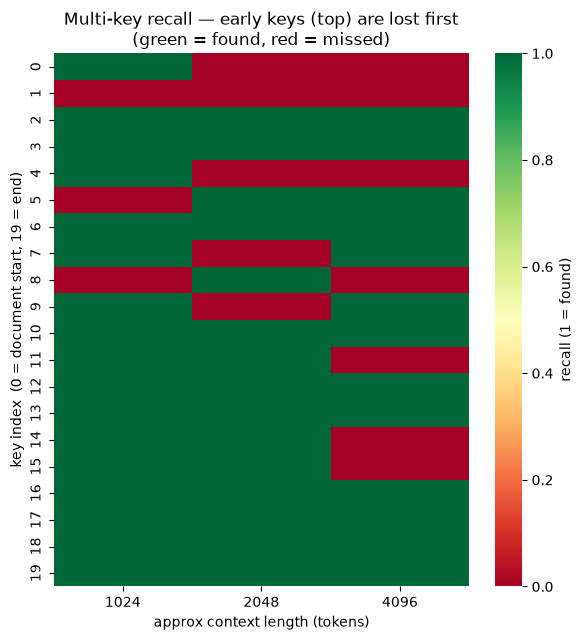

In [ ]:
pivot = mdf.pivot_table(index="query_index", columns="n_tokens", values="hit")
fig, ax = plt.subplots(figsize=(6, 6.5))
sns.heatmap(pivot, cmap="RdYlGn", vmin=0, vmax=1,
            cbar_kws={"label": "recall (1 = found)"}, ax=ax)
ax.set_title("Multi-key recall — early keys (top) are lost first\n(green = found, red = missed)")
ax.set_xlabel("approx context length (tokens)")
ax.set_ylabel("key index  (0 = document start, 19 = end)")
plt.tight_layout()
plt.show()

## 5. What this means for memory research

What we just measured frames the rest of the lab:

- **The cache is the budget.** Memory grows linearly with context and per-token latency rises with it — so "just use a longer context" has a hard, measurable ceiling on 32 GB.
- **Not all tokens are equal.** Sinks, recency, and a handful of long-range heads carry the load. Eviction/compression must be *structure-aware*, not uniform.
- **Recall depends on interference, not just length.** A lone needle is trivial at 4k, yet twenty confusable keys crack the same 0.5B model — with a pronounced *recency bias* (it keeps the latest keys, loses the earliest). Bigger context ≠ usable memory.

Concrete threads this opens (and where we take them next):

- **Retrieval instead of stuffing** (Notebooks 08–10): keep the prompt short, fetch the needle on demand — compare recall against the curves above.
- **Cache compression / eviction**: replay the multi-key grid while dropping non-sink, non-recent KV and chart the quality/memory trade-off.
- **Summarization memory**: compress old turns and measure recall retention per token spent.

Every one of these is now a controlled experiment, because we have the baselines and the harness.

In [ ]:
import json

summary = {
    "model": lm.model_id,
    "device": lm.device,
    "kv_formula_exact": bool(kv_exact),
    "scaling": df[["seq_len", "prefill_ms", "decode_ms_per_tok", "kv_mib"]].round(3).to_dict(orient="records"),
    "max_head_sink": round(float(head_sink.max()), 3),
    "single_needle_recall": round(float(sdf.hit.mean()), 3),
    "multikey_recall": round(float(mdf.hit.mean()), 3),
    "multikey_recall_by_depth": {
        str(k): round(float(v), 3) for k, v in mdf.groupby("depth").hit.mean().items()
    },
}
path = config.RESULTS_DIR / "05_attention_and_kv_cache.json"
path.write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))
print("\nwrote", path)

{
  "model": "Qwen/Qwen2.5-0.5B-Instruct",
  "device": "mps",
  "kv_formula_exact": true,
  "scaling": [
    {
      "seq_len": 128,
      "prefill_ms": 52.849,
      "decode_ms_per_tok": 22.689,
      "kv_mib": 3.0
    },
    {
      "seq_len": 256,
      "prefill_ms": 87.264,
      "decode_ms_per_tok": 23.665,
      "kv_mib": 6.0
    },
    {
      "seq_len": 512,
      "prefill_ms": 173.477,
      "decode_ms_per_tok": 37.488,
      "kv_mib": 12.0
    },
    {
      "seq_len": 1024,
      "prefill_ms": 371.712,
      "decode_ms_per_tok": 30.716,
      "kv_mib": 24.0
    },
    {
      "seq_len": 2048,
      "prefill_ms": 894.803,
      "decode_ms_per_tok": 39.283,
      "kv_mib": 48.0
    },
    {
      "seq_len": 4096,
      "prefill_ms": 2551.559,
      "decode_ms_per_tok": 57.241,
      "kv_mib": 96.0
    }
  ],
  "max_head_sink": 1.0,
  "single_needle_recall": 1.0,
  "multikey_recall": 0.75,
  "multikey_recall_by_depth": {
    "0.0": 0.333,
    "0.053": 0.0,
    "0.105": 1.0,
   